In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoProcessor, LlavaForConditionalGeneration
from PIL import Image
import time
import threading
import requests

/home/eros483/miniconda3/envs/deepLure/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_id = "llava-hf/llava-1.5-7b-hf"
image_url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/car.jpg"
MAX_VRAM_MB=46068
BATCH_SIZE=30
MAX_TOKENS=300

In [3]:
timestamps = []
vram_usage = []
start_time = None
monitoring = False
markers = []

In [4]:
def monitor_vram(interval=0.05):
    """Background thread to monitor vRAM"""
    global monitoring, timestamps, vram_usage, start_time
    while monitoring:
        if torch.cuda.is_available():
            current_time = (time.time() - start_time) * 1000
            allocated_mb = torch.cuda.memory_allocated() / (1024 ** 2)
            reserved_mb = torch.cuda.memory_reserved() / (1024 ** 2)
            timestamps.append(current_time)
            vram_usage.append((allocated_mb, reserved_mb))  # Now a tuple!
        time.sleep(interval)

def add_marker(label):
    """Add a marker at current time"""
    if torch.cuda.is_available():
        current_time = (time.time() - start_time) * 1000
        allocated = torch.cuda.memory_allocated() / (1024 ** 2)
        reserved = torch.cuda.memory_reserved() / (1024 ** 2)
        markers.append((current_time, allocated, reserved, label))
        print(f"[{current_time:.1f}ms] {label}:")
        print(f"  Allocated: {allocated:.1f} MB")
        print(f"  Reserved:  {reserved:.1f} MB")
        print(f"  Gap:       {reserved - allocated:.1f} MB")

In [5]:
if not torch.cuda.is_available():
    raise RuntimeError("CUDA not available. GPU required for profiling.")

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

monitoring = True
start_time = time.time()
monitor_thread = threading.Thread(target=monitor_vram, daemon=True)
monitor_thread.start()

time.sleep(0.1)
add_marker("Start")

[100.8ms] Start:
  Allocated: 0.0 MB
  Reserved:  0.0 MB
  Gap:       0.0 MB


- **Loading Processor**

In [6]:
processor = AutoProcessor.from_pretrained(model_id)
add_marker("Processor Loaded")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


[4556.3ms] Processor Loaded:
  Allocated: 0.0 MB
  Reserved:  0.0 MB
  Gap:       0.0 MB


- **Loading Model**

In [7]:
model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)
add_marker("Model Loaded")

time.sleep(0.2)

`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 3/3 [00:00<00:00,  4.16it/s]


[6397.1ms] Model Loaded:
  Allocated: 13472.4 MB
  Reserved:  13490.0 MB
  Gap:       17.6 MB


- **Batching 15 requests for inference**

In [8]:
images = []
prompts = []

for i in range(BATCH_SIZE):
    image = Image.open(requests.get(image_url, stream=True).raw)
    images.append(image)
    prompts.append(f"USER: <image>\nWhat is in this image? (Request {i+1})\nASSISTANT:")

add_marker(f"Batch: {BATCH_SIZE} Images Loaded")

batched_inputs = processor(
    text=prompts, 
    images=images, 
    return_tensors="pt",
    padding=True
)
batched_inputs = {k: v.to(model.device) for k, v in batched_inputs.items()}

add_marker(f"Batch: {BATCH_SIZE} Inputs Prepared")

with torch.no_grad():
    batched_outputs = model.generate(**batched_inputs, max_new_tokens=MAX_TOKENS)

for i in range(min(3, BATCH_SIZE)):  # printing only first 3
    generated_text = processor.decode(batched_outputs[i], skip_special_tokens=True)
    print(f"\nRequest {i+1}: {generated_text[:80]}...")

add_marker("Batch: Decoding Complete")


[20478.6ms] Batch: 30 Images Loaded:
  Allocated: 13472.4 MB
  Reserved:  13490.0 MB
  Gap:       17.6 MB
[20632.8ms] Batch: 30 Inputs Prepared:
  Allocated: 13511.5 MB
  Reserved:  13530.0 MB
  Gap:       18.5 MB

Request 1: USER:  
What is in this image? (Request 1)
ASSISTANT: The image features a blue ...

Request 2: USER:  
What is in this image? (Request 2)
ASSISTANT: The image features a vinta...

Request 3: USER:  
What is in this image? (Request 3)
ASSISTANT: The image features a vinta...
[27234.1ms] Batch: Decoding Complete:
  Allocated: 13520.7 MB
  Reserved:  29118.0 MB
  Gap:       15597.3 MB


In [9]:
time.sleep(0.2)
monitoring = False
monitor_thread.join(timeout=1.0)

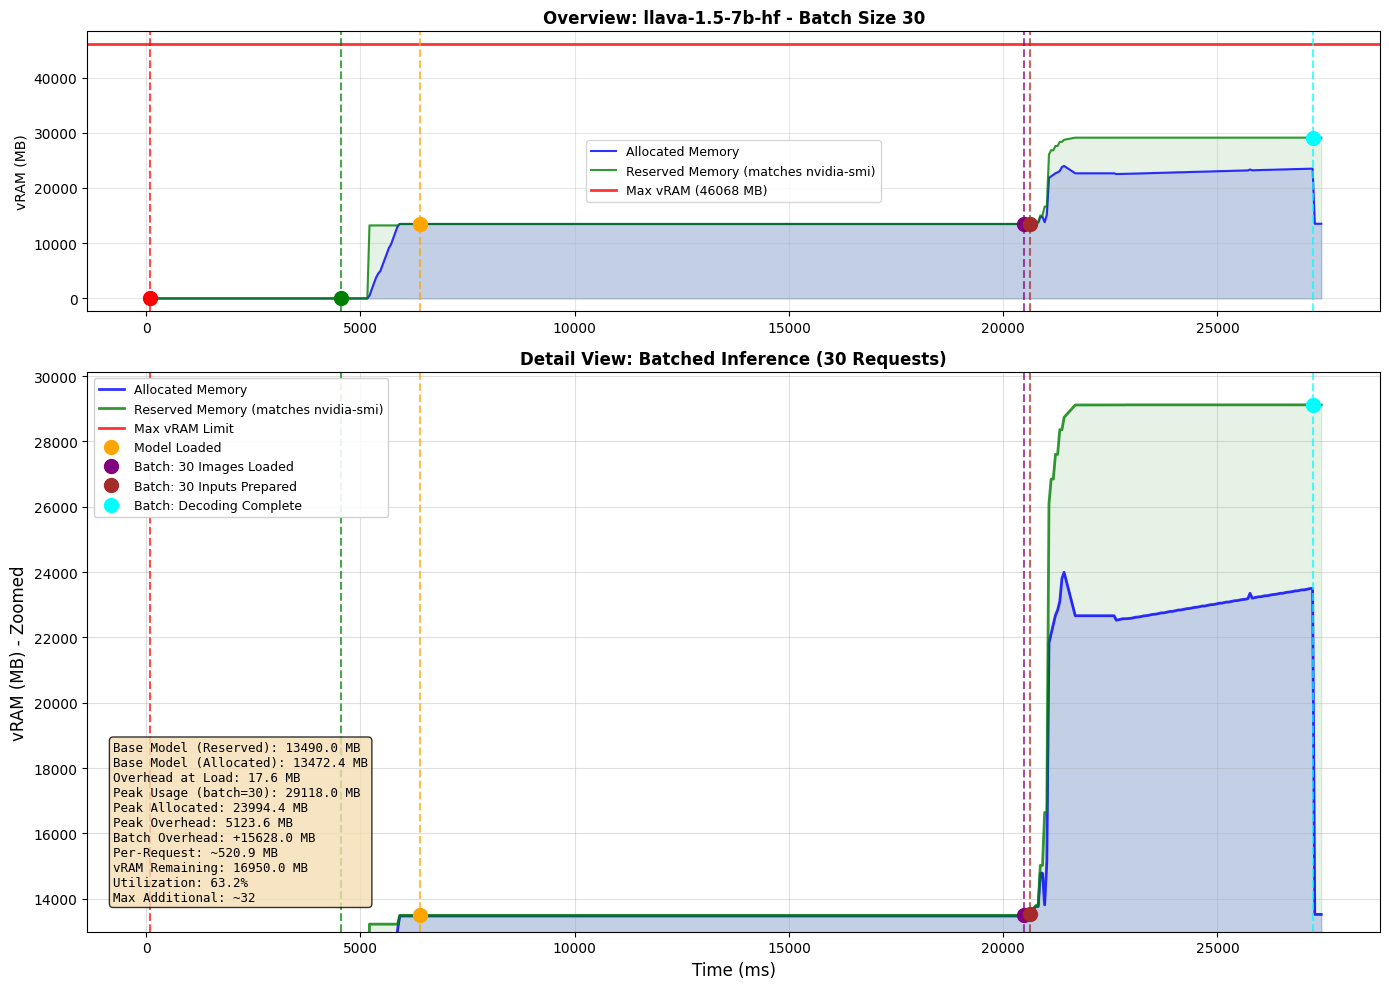

In [10]:
import matplotlib.pyplot as plt

model_loaded_allocated = next((alloc for t, alloc, res, l in markers if l == "Model Loaded"), 0)
model_loaded_reserved = next((res for t, alloc, res, l in markers if l == "Model Loaded"), 0)

allocated_usage = [alloc for alloc, res in vram_usage]
reserved_usage = [res for alloc, res in vram_usage]

max_allocated = max(allocated_usage) if allocated_usage else 0
max_reserved = max(reserved_usage) if reserved_usage else 0

y_zoom_min = model_loaded_reserved - 500
y_zoom_max = max_reserved + 1000

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1, 2]})

ax1.plot(timestamps, allocated_usage, 'b-', linewidth=1.5, label='Allocated Memory', alpha=0.8)
ax1.plot(timestamps, reserved_usage, 'g-', linewidth=1.5, label='Reserved Memory (matches nvidia-smi)', alpha=0.8)
ax1.axhline(y=MAX_VRAM_MB, color='red', linestyle='-', linewidth=2, label=f'Max vRAM ({MAX_VRAM_MB:.0f} MB)', alpha=0.8)
ax1.fill_between(timestamps, allocated_usage, alpha=0.15, color='blue')
ax1.fill_between(timestamps, reserved_usage, alpha=0.10, color='green')
ax1.set_title(f'Overview: {model_id.split("/")[-1]} - Batch Size {BATCH_SIZE}', fontsize=12, fontweight='bold')
ax1.set_ylabel('vRAM (MB)')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best', fontsize=9)

ax2.plot(timestamps, allocated_usage, 'b-', linewidth=2, label='Allocated Memory', alpha=0.8)
ax2.plot(timestamps, reserved_usage, 'g-', linewidth=2, label='Reserved Memory (matches nvidia-smi)', alpha=0.8)
ax2.axhline(y=MAX_VRAM_MB, color='red', linestyle='-', linewidth=2, label=f'Max vRAM Limit', alpha=0.8)
ax2.fill_between(timestamps, allocated_usage, alpha=0.15, color='blue')
ax2.fill_between(timestamps, reserved_usage, alpha=0.10, color='green')

ax2.set_ylim(y_zoom_min, y_zoom_max)
ax2.set_title(f'Detail View: Batched Inference ({BATCH_SIZE} Requests)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Time (ms)', fontsize=12)
ax2.set_ylabel('vRAM (MB) - Zoomed', fontsize=12)
ax2.grid(True, alpha=0.4, which='both')

colors = ['red', 'green', 'orange', 'purple', 'brown', 'cyan']
for ax in [ax1, ax2]:
    for i, (t, alloc, res, label) in enumerate(markers):
        color = colors[i % len(colors)]
        ax.axvline(x=t, color=color, linestyle='--', alpha=0.7, linewidth=1.5)
        should_label = False
        if ax == ax1:
            should_label = True
        elif ax == ax2 and (y_zoom_min <= res <= y_zoom_max):
            should_label = True
            
        if should_label:
            ax.plot(t, res, 'o', color=color, markersize=10, label=label)
        else:
            if ax == ax1 or (y_zoom_min <= res <= y_zoom_max):
                ax.plot(t, res, 'o', color=color, markersize=10)

ax2.legend(loc='upper left', fontsize=9, ncol=1, framealpha=0.9)

inference_delta = max_reserved - model_loaded_reserved
vram_remaining = MAX_VRAM_MB - max_reserved
utilization_pct = (max_reserved / MAX_VRAM_MB) * 100
vram_per_request = inference_delta / BATCH_SIZE
potential_max_batch = int(vram_remaining / vram_per_request) if vram_per_request > 0 else 0

overhead_at_model = model_loaded_reserved - model_loaded_allocated
overhead_at_peak = max_reserved - max_allocated

stats_text = (f"Base Model (Reserved): {model_loaded_reserved:.1f} MB\n"
              f"Base Model (Allocated): {model_loaded_allocated:.1f} MB\n"
              f"Overhead at Load: {overhead_at_model:.1f} MB\n"
              f"Peak Usage (batch={BATCH_SIZE}): {max_reserved:.1f} MB\n"
              f"Peak Allocated: {max_allocated:.1f} MB\n"
              f"Peak Overhead: {overhead_at_peak:.1f} MB\n"
              f"Batch Overhead: +{inference_delta:.1f} MB\n"
              f"Per-Request: ~{vram_per_request:.1f} MB\n"
              f"vRAM Remaining: {vram_remaining:.1f} MB\n"
              f"Utilization: {utilization_pct:.1f}%\n"
              f"Max Additional: ~{potential_max_batch}")

ax2.text(0.02, 0.05, stats_text, transform=ax2.transAxes,
        verticalalignment='bottom', bbox=dict(boxstyle='round',
        facecolor='wheat', alpha=0.8), fontsize=9, family='monospace')

plt.tight_layout()
plt.savefig('../metrics/vram_profile_batch_inference_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
markers

[(100.80480575561523, 0.0, 0.0, 'Start'),
 (4556.318998336792, 0.0, 0.0, 'Processor Loaded'),
 (6397.117137908936, 13472.42333984375, 13490.0, 'Model Loaded'),
 (20478.62148284912, 13472.42333984375, 13490.0, 'Batch: 30 Images Loaded'),
 (20632.842540740967, 13511.45849609375, 13530.0, 'Batch: 30 Inputs Prepared'),
 (27234.123945236206, 13520.736328125, 29118.0, 'Batch: Decoding Complete')]

In [14]:
def predict_inference_timeline(batch_size, n_tokens):
    t_start = 100.55

    t_processor = t_start + 4900 

    t_model = t_processor + 2500
    
    # 640 ms per image for image loading
    duration_load = (0.46 * batch_size) * 1000
    t_images = t_model + duration_load
    
    # 5 ms per image for input preparation
    duration_prep = (0.005 * batch_size) * 1000
    t_inputs = t_images + duration_prep

    overhead_fixed = 800 
    
    # prefill takes 150 ms per image
    duration_prefill = (140 * batch_size)
    
    # Generating 1 token takes ~0.35ms per batch item
    duration_decode = (0.35 * batch_size * n_tokens)
    
    t_complete = t_inputs + overhead_fixed + duration_prefill + duration_decode
    
    print(f"{t_start:>10.2f} ms : Start")
    print(f"{t_processor:>10.2f} ms : Processor Loaded")
    print(f"{t_model:>10.2f} ms : Model Loaded")
    print(f"{t_images:>10.2f} ms : Batch Images Loaded (+{duration_load/1000:.1f}s)")
    print(f"{t_inputs:>10.2f} ms : Inputs Prepared")
    print(f"{t_complete:>10.2f} ms : Decoding Complete (+{(t_complete-t_inputs)/1000:.1f}s)")


In [15]:
predict_inference_timeline(BATCH_SIZE, MAX_TOKENS)

    100.55 ms : Start
   5000.55 ms : Processor Loaded
   7500.55 ms : Model Loaded
  21300.55 ms : Batch Images Loaded (+13.8s)
  21450.55 ms : Inputs Prepared
  29600.55 ms : Decoding Complete (+8.2s)
